In [18]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Machine Learning 
## Topic: Logistic Regression — Classification from First Principles

**Prerequisites you already have:** Python, Linear Algebra, and Day 1's Linear Regression (hypothesis function, MSE loss, gradient descent, train/test split, evaluation with scikit-learn)

---
### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain what a classification problem is and why linear regression is the wrong tool for it
2. Understand and derive the sigmoid (logistic) function
3. Explain the decision boundary and how probabilities become class predictions
4. Understand and derive the Binary Cross-Entropy (Log Loss) function
5. Understand gradient descent for logistic regression
6. Implement logistic regression **from scratch** using only NumPy
7. Implement logistic regression using **scikit-learn**
8. Evaluate a classifier using accuracy, precision, recall, F1-score, confusion matrix
9. Understand why "accuracy" alone can be misleading


# Part 1: What is Classification, and Why Not Just Use Linear Regression?

Recall from Day 1: **regression** predicts a continuous number (e.g., exam score, house price).

**Classification** predicts a **category/class** instead. The simplest case is **binary classification** — only two possible outcomes.

| Problem | Input | Output (classes) |
|---|---|---|
| Will a student pass or fail? | Hours studied | Pass (1) / Fail (0) |
| Is this email spam? | Email text features | Spam (1) / Not Spam (0) |
| Does a patient have the disease? | Test results | Disease (1) / No Disease (0) |
| Will a customer churn? | Usage data | Churn (1) / Stay (0) |

We label the two classes as **0** and **1** (this is just a convention — "1" usually means the thing we're trying to detect/predict).

### Today's running example
We'll predict whether a student **passes (1)** or **fails (0)** an exam, based on **hours studied**.

## Why can't we just reuse Linear Regression here?

Let's actually try it and see what goes wrong. This will motivate everything else in today's lecture.


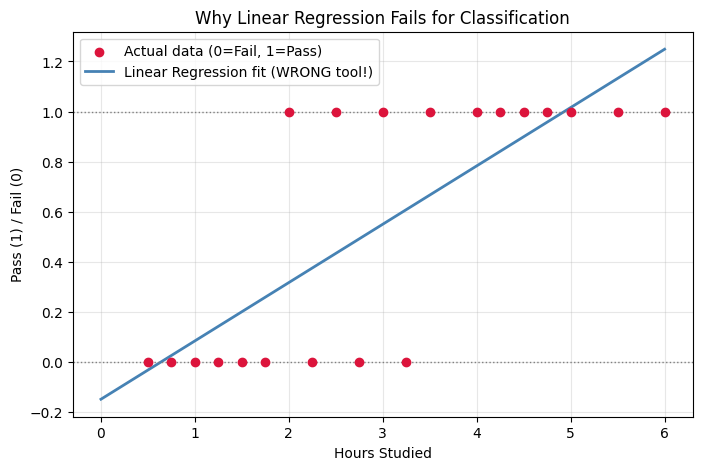

Problems visible in this plot:
1. The line predicts values below 0 and above 1 -- but probabilities must be between 0 and 1!
2. A straight line doesn't naturally model a 0/1 'jump' -- real class boundaries are more like a step or S-curve.
3. Outliers (e.g. a very high 'hours studied' student) would badly distort the whole line.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a simple pass/fail dataset
np.random.seed(42)
hours = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75,
                   3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0])
# Roughly: students who studied more are more likely to pass (1), but not a hard cutoff
passed = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
                    1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

plt.figure(figsize=(8, 5))
plt.scatter(hours, passed, color='crimson', zorder=3, label='Actual data (0=Fail, 1=Pass)')

# Now let's fit an ordinary LINEAR regression line to this data, just to see what happens
w_lin = np.polyfit(hours, passed, 1)[0] #degree-1 polynomial
b_lin = np.polyfit(hours, passed, 1)[1]
#Or in one line: w_lin, b_lin = np.polyfit(hours, passed, 1)
x_line = np.linspace(0, 6, 100)
y_line = w_lin * x_line + b_lin
plt.plot(x_line, y_line, color='steelblue', linewidth=2, label='Linear Regression fit (WRONG tool!)')

plt.axhline(y=0, color='gray', linestyle=':', linewidth=1)
plt.axhline(y=1, color='gray', linestyle=':', linewidth=1)
plt.title("Why Linear Regression Fails for Classification")
plt.xlabel("Hours Studied")
plt.ylabel("Pass (1) / Fail (0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Problems visible in this plot:")
print("1. The line predicts values below 0 and above 1 -- but probabilities must be between 0 and 1!")
print("2. A straight line doesn't naturally model a 0/1 'jump' -- real class boundaries are more like a step or S-curve.")
print("3. Outliers (e.g. a very high 'hours studied' student) would badly distort the whole line.")


### The problem, summarized

Linear regression outputs **any real number** ($-\infty$ to $+\infty$), but for classification we want to output a **probability** — a number strictly between **0 and 1** (e.g., "80% chance this student passes").

We need a function that:
1. Takes any real number as input (our familiar $wx + b$)
2. **Squashes** it into the range $(0, 1)$
3. Produces an **S-shaped curve** so that predictions smoothly transition from "definitely class 0" to "definitely class 1"

This function is the **sigmoid function**.


# Part 2: The Sigmoid Function

## Definition

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Where:
- $z$ is any real number (in our case, $z = wx + b$, exactly the same linear expression as Day 1!)
- $e$ is Euler's number ($\approx 2.71828$)
- $\sigma(z)$ (sigma of z) is the output, always between 0 and 1

## Why does this formula squash values into (0, 1)? Let's reason through it:

- If $z$ is a **large positive** number (e.g., $z = 10$): $e^{-z}$ becomes tiny (close to 0), so $\sigma(z) \approx \frac{1}{1+0} = 1$
- If $z$ is a **large negative** number (e.g., $z = -10$): $e^{-z}$ becomes huge, so $\sigma(z) \approx \frac{1}{1+\text{huge}} \approx 0$
- If $z = 0$: $e^{0} = 1$, so $\sigma(0) = \frac{1}{1+1} = 0.5$ exactly in the middle

So as $z$ ranges from $-\infty$ to $+\infty$, $\sigma(z)$ smoothly ranges from $0$ to $1$, always passing through exactly $0.5$ at $z=0$. This creates the characteristic **S-shaped curve**.

## The Full Logistic Regression Model

$$
z = wx + b \quad \text{(exact same linear part as Day 1 linear regression!)}
$$
$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-(wx+b)}}
$$

Here $\hat{y}$ is interpreted as: **"the probability that the class is 1"**, i.e. $\hat{y} = P(y=1 \mid x)$.

**Key insight:** Logistic Regression is just Linear Regression's output passed through the sigmoid squashing function. Everything you learned on Day 1 about $w$, $b$, and the linear combination of features still applies directly here.


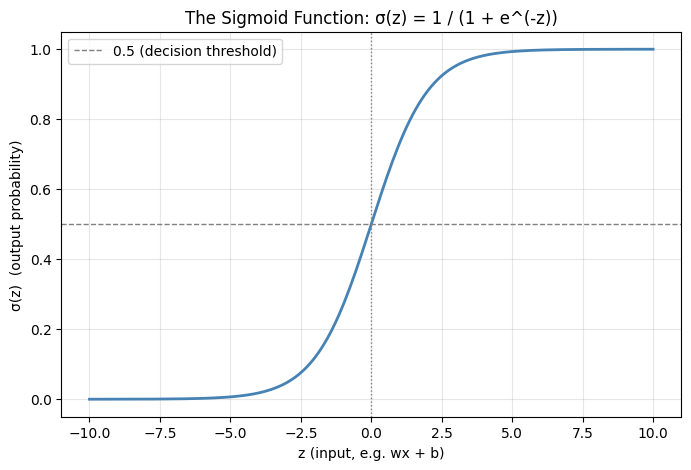

sigmoid(-10) = 0.000045  (very close to 0)
sigmoid(0)   = 0.500000  (exactly 0.5)
sigmoid(10)  = 0.999955  (very close to 1)


In [20]:
# Let's plot the sigmoid function itself to see the S-curve clearly

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values, color='steelblue', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='0.5 (decision threshold)')
plt.axvline(x=0, color='gray', linestyle=':', linewidth=1)
plt.title("The Sigmoid Function: σ(z) = 1 / (1 + e^(-z))")
plt.xlabel("z (input, e.g. wx + b)")
plt.ylabel("σ(z)  (output probability)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Verify our reasoning with actual numbers
print(f"sigmoid(-10) = {sigmoid(-10):.6f}  (very close to 0)")
print(f"sigmoid(0)   = {sigmoid(0):.6f}  (exactly 0.5)")
print(f"sigmoid(10)  = {sigmoid(10):.6f}  (very close to 1)")


# Part 3: From Probability to Class Prediction — The Decision Boundary

Our model outputs a **probability** $\hat{y}$ between 0 and 1. But at the end, we usually need an actual **class label** (0 or 1). We convert probability to class using a **threshold**, typically **0.5**:

$$
\text{predicted class} =
\begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{if } \hat{y} < 0.5
\end{cases}
$$

Since $\sigma(z) = 0.5$ exactly when $z = 0$, this means:

$$
\text{predicted class} = 1 \iff wx + b \geq 0
$$

The point where $wx + b = 0$ is called the **decision boundary** — the "dividing line" between predicting class 0 and class 1. For one feature, this is a single point on the x-axis (the "hours studied" value above which we predict Pass). For two features, it becomes a line; for more features, a hyperplane (again, linear algebra!).

### Important note on the threshold
0.5 is the *default* threshold, but it's not fixed forever. In some real applications (e.g., detecting a serious disease), we might lower the threshold to 0.3 so we catch more true positive cases, even if it means more false alarms. 

# Part 4: Why Can't We Reuse MSE? — Binary Cross-Entropy Loss

On Day 1, we used **MSE** as our loss function for Linear Regression. A natural question: why not use MSE for Logistic Regression too?

**The problem:** When MSE is combined with the sigmoid function, the resulting loss surface is **not convex** (it has many bumpy hills and valleys, not one smooth bowl). This means gradient descent can get stuck in a **local minimum** instead of finding the actual best solution. We need a different loss function specifically designed for probabilities.

---

## Mathematical Derivation of Binary Cross-Entropy Loss

* For binary classification we have $y = 0, 1$

$$\text{If } y = 1 \implies P(y=1|x) = \hat{y}$$
$$\text{If } y = 0 \implies P(y=0|x) = (1 - \hat{y})$$

#### Combined $\implies P(y|x)$
Can be written as a single expression using exponents:
$$P(y|x) = \hat{y}^y \cdot (1 - \hat{y})^{(1 - y)}$$

Let's double-check how this beautiful shortcut works:
$$\text{If } y = 1 \implies P(y|x) = \hat{y}^1 \cdot (1 - \hat{y})^0 = \hat{y}$$
$$\text{If } y = 0 \implies P(y|x) = \hat{y}^0 \cdot (1 - \hat{y})^1 = (1 - \hat{y})$$

---

### Step 1: Taking the Logarithm
To find the best model weights, we need to maximize the total probability across our data. However, multiplying long chains of decimals causes numbers to shrink to zero, which breaks computers. 

To fix this, we take the log because the log converts dangerous multiplications into clean, safe additions:

$$\log P(y|x) = \log \left( \hat{y}^y \cdot (1 - \hat{y})^{(1 - y)} \right)$$

Using log properties ($\log(A \cdot B) = \log A + \log B$ and $\log A^b = b \log A$), the exponents drop down:
$$\log P(y|x) = y \log \hat{y} + (1 - y) \log (1 - \hat{y})$$

---

### Step 2: Flipping to a "Loss" Function
We want to maximize this log probability, but machine learning optimization algorithms are designed to minimize an error score. To turn this into a **Loss Function** that we can minimize, we multiply the entire equation by $-1$:

$$\therefore L(\hat{y}, y) = - \log P(y|x) = - \big[ y \log \hat{y} + (1 - y) \log (1 - \hat{y}) \big]$$

---

## Let's Break Down the Intuition, Case by Case:

**Case 1: True label $y = 1$** (The actual answer is "Yes")
The second term has a $(1-1)=0$ multiplier and completely vanishes, simplifying to:
$$L = -\log(\hat{y})$$
* If our model correctly predicts $\hat{y}$ close to 1 (confident & correct) $\to -\log(1) = 0 \to$ **loss ≈ 0** (no penalty).
* If our model wrongly predicts $\hat{y}$ close to 0 (confident but WRONG) $\to -\log(\text{tiny}) \to \infty \to$ **loss → huge penalty!**

**Case 2: True label $y = 0$** (The actual answer is "No")
The first term has a $y=0$ multiplier and completely vanishes, simplifying to:
$$L = -\log(1-\hat{y})$$
* If our model correctly predicts $\hat{y}$ close to 0 (confident & correct) $\to -\log(1 - 0) = 0 \to$ **loss ≈ 0** (no penalty).
* If our model wrongly predicts $\hat{y}$ close to 1 (confident but WRONG) $\to -\log(\text{tiny}) \to \infty \to$ **loss → huge penalty!**

> **Key Takeaway:** Cross-entropy loss **harshly punishes confident, wrong predictions** far more than MSE would. Predicting a 99% probability for the wrong class is penalized exponentially, which is exactly what a probability-based model needs to learn efficiently.

---

## Total Loss Over the Whole Dataset

To evaluate our model across all $m$ examples in our dataset, we simply take the average of our single-point losses:

$$J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \big[ y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i) \big]$$

This is exactly what `scikit-learn` (and virtually every modern machine learning framework) minimizes internally when training a logistic regression model.

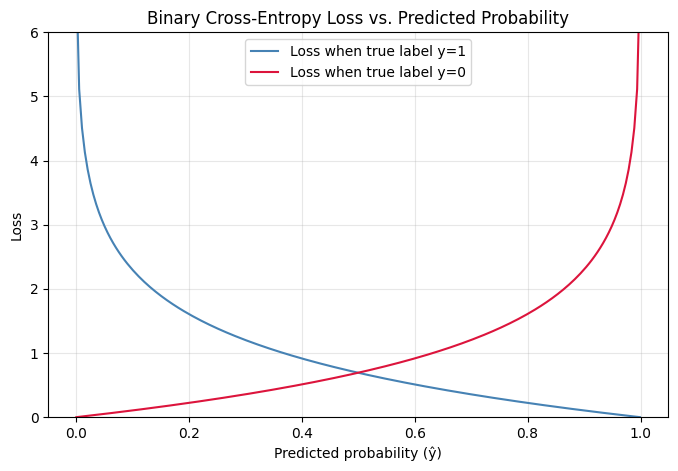

Notice: each curve shoots up towards infinity as the prediction gets confidently WRONG.
E.g., if true label is 1 but model predicts ŷ=0.01 (99% sure it's 0), the loss is huge.


In [21]:
# Let's visualize WHY cross-entropy punishes confident wrong answers so harshly,
# compared to how gentle it is when the prediction is confident AND correct.

y_hat_range = np.linspace(0.001, 0.999, 200)  # avoid exactly 0 or 1 (log undefined there)

loss_if_true_label_is_1 = -np.log(y_hat_range)
loss_if_true_label_is_0 = -np.log(1 - y_hat_range)

plt.figure(figsize=(8, 5))
plt.plot(y_hat_range, loss_if_true_label_is_1, color='steelblue', label='Loss when true label y=1')
plt.plot(y_hat_range, loss_if_true_label_is_0, color='crimson', label='Loss when true label y=0')
plt.title("Binary Cross-Entropy Loss vs. Predicted Probability")
plt.xlabel("Predicted probability (ŷ)")
plt.ylabel("Loss")
plt.ylim(0, 6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: each curve shoots up towards infinity as the prediction gets confidently WRONG.")
print("E.g., if true label is 1 but model predicts ŷ=0.01 (99% sure it's 0), the loss is huge.")


# Part 5: Gradient Descent for Logistic Regression

Just like Day 1, we use **gradient descent** to find the $w, b$ that minimize the loss $J(w,b)$.

## The gradients (derived using calculus - chain rule through the sigmoid and log terms)

Remarkably, after all the calculus simplifies, the gradients have the **exact same form** as linear regression's gradients:

$$
\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)\cdot x_i
$$
$$
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)
$$

The **only difference** from Day 1 is that $\hat{y}_i$ here is $\sigma(wx_i + b)$ (a probability from the sigmoid), instead of $wx_i + b$ directly.

## Update rule (identical structure to Day 1)

$$
w := w - \alpha \cdot \frac{\partial J}{\partial w}, \qquad b := b - \alpha \cdot \frac{\partial J}{\partial b}
$$

Same idea as before: take small steps ($\alpha$ = learning rate) in the direction that reduces the loss, repeated over many epochs.

**This is why Day 1 was essential preparation** — logistic regression reuses the entire gradient descent machinery; only the model's output (sigmoid) and the loss function (cross-entropy) changed.


## The Complete Mathematical Proof: Why Gradients Match

To understand how the Chain Rule applies here without needing a neural network, let's trace our forward math step-by-step for a single data point:

1. **The Linear Line:** $z = wx + b$
2. **The Sigmoid Prediction:** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. **The Loss Function:** $L = -\big[ y \log \hat{y} + (1 - y) \log(1 - \hat{y}) \big]$

We want to know how a tiny change in our weight ($w$) affects our final Loss ($L$). In calculus, this is written as $\frac{\partial L}{\partial w}$. 

Because $w$ changes $z$, $z$ changes $\hat{y}$, and $\hat{y}$ changes $L$, the **Chain Rule** tells us we can multiply their individual rates of change together:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Let's solve these three pieces one by one.

---

### Step 1: Derivative of Loss with respect to Prediction $\left(\frac{\partial L}{\partial \hat{y}}\right)$

Our loss equation is:  
$L = -y \log \hat{y} - (1 - y) \log(1 - \hat{y})$

Remember from calculus that the derivative of $\log(x)$ is $\frac{1}{x}$, and using the chain rule for $\log(1-x)$ gives $\frac{-1}{1-x}$. Let's take the derivative with respect to $\hat{y}$:

$$\frac{\partial L}{\partial \hat{y}} = -y \left(\frac{1}{\hat{y}}\right) - (1 - y) \left(\frac{-1}{1 - \hat{y}}\right)$$

$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}}$$

Let's combine these into a single fraction by finding a common denominator:

$$\frac{\partial L}{\partial \hat{y}} = \frac{-y(1 - \hat{y}) + \hat{y}(1 - y)}{\hat{y}(1 - \hat{y})}$$

$$\frac{\partial L}{\partial \hat{y}} = \frac{-y + y\hat{y} + \hat{y} - y\hat{y}}{\hat{y}(1 - \hat{y})}$$

$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$

---

### Step 2: Derivative of Sigmoid with respect to the Line $\left(\frac{\partial \hat{y}}{\partial z}\right)$

Our prediction equation is:  
$$\hat{y} = (1 + e^{-z})^{-1}$$

Using the power rule and chain rule from calculus:

$$\frac{\partial \hat{y}}{\partial z} = -1(1 + e^{-z})^{-2} \cdot \left(e^{-z} \cdot -1\right)$$

$$\frac{\partial \hat{y}}{\partial z} = \frac{e^{-z}}{(1 + e^{-z})^2}$$

Let's split this fraction apart using a clever algebra trick:

$$\frac{\partial \hat{y}}{\partial z} = \left(\frac{1}{1 + e^{-z}}\right) \cdot \left(\frac{e^{-z}}{1 + e^{-z}}\right)$$

Notice that $\frac{1}{1 + e^{-z}}$ is exactly our definition of $\hat{y}$. Also, notice that $\frac{e^{-z}}{1 + e^{-z}}$ can be rewritten as $\frac{1 + e^{-z} - 1}{1 + e^{-z}} = 1 - \hat{y}$. 

Therefore, the derivative of the Sigmoid function simplifies beautifully to:
$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$

---

### Step 3: Derivative of the Line with respect to Weight $\left(\frac{\partial z}{\partial w}\right)$

Our line equation is:  
$z = wx + b$

Taking the derivative with respect to $w$ treats $b$ as a constant ($0$) and leaves us with just:
$$\frac{\partial z}{\partial w} = x$$

*(Note: If we took the derivative with respect to the bias $b$, $\frac{\partial z}{\partial b} = 1$)*

---

### Step 4: Multiplying It All Together (The Big Magic Trick)

Now we assemble our Chain Rule puzzle pieces:

$$\frac{\partial L}{\partial w} = \color{crimson}{\frac{\partial L}{\partial \hat{y}}} \cdot \color{steelblue}{\frac{\partial \hat{y}}{\partial z}} \cdot \color{forestgreen}{\frac{\partial z}{\partial w}}$$

$$\frac{\partial L}{\partial w} = \color{crimson}{\left( \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \right)} \cdot \color{steelblue}{\Big( \hat{y}(1 - \hat{y}) \Big)} \cdot \color{forestgreen}{x}$$

Look closely! The denominator $\hat{y}(1 - \hat{y})$ from the loss derivative perfectly cancels out the entire sigmoid derivative multiplying it!

$$\frac{\partial L}{\partial w} = (\hat{y} - y) \cdot x$$

---

### Final Global Loss Gradient $J(w,b)$

Because our total dataset loss $J(w,b)$ is simply the average of all single-point losses ($J = \frac{1}{m}\sum L$), we sum up this result for all $m$ examples:

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)\cdot x_i$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)$$

## Let's implement Logistic Regression completely from scratch (NumPy only)

We'll use our small pass/fail dataset from earlier.


In [22]:
# From-scratch Logistic Regression using Gradient Descent

X = hours.copy()     # hours studied (our single feature)
y = passed.copy()    # true labels: 0 = Fail, 1 = Pass
m = len(X)

# Initialize parameters
w = 0.0
b = 0.0

learning_rate = 0.1
epochs = 5000
loss_history = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    # ---- Forward pass ----
    z = w * X + b
    y_hat = sigmoid(z)   # predicted probabilities

    # ---- Compute Binary Cross-Entropy Loss ----
    # small epsilon added to avoid log(0), which is undefined
    eps = 1e-9
    loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    loss_history.append(loss)

    # ---- Compute gradients (same form as linear regression!) ----
    dw = (1/m) * np.sum((y_hat - y) * X)
    db = (1/m) * np.sum((y_hat - y))

    # ---- Update parameters ----
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | w = {w:.4f} | b = {b:.4f}")

print(f"\nFinal learned parameters: w = {w:.4f}, b = {b:.4f}")

# What hours-studied value is our decision boundary? (where wx + b = 0)
decision_boundary = -b / w
print(f"Decision boundary: students need to study more than {decision_boundary:.2f} hours to be predicted as 'Pass'")


Epoch    0 | Loss: 0.6931 | w = 0.0750 | b = 0.0050
Epoch  500 | Loss: 0.3354 | w = 1.2320 | b = -3.0692
Epoch 1000 | Loss: 0.3145 | w = 1.5512 | b = -4.0109
Epoch 1500 | Loss: 0.3094 | w = 1.7119 | b = -4.4765
Epoch 2000 | Loss: 0.3078 | w = 1.8047 | b = -4.7433
Epoch 2500 | Loss: 0.3072 | w = 1.8617 | b = -4.9069
Epoch 3000 | Loss: 0.3070 | w = 1.8981 | b = -5.0107
Epoch 3500 | Loss: 0.3069 | w = 1.9217 | b = -5.0782
Epoch 4000 | Loss: 0.3068 | w = 1.9372 | b = -5.1225
Epoch 4500 | Loss: 0.3068 | w = 1.9475 | b = -5.1518

Final learned parameters: w = 1.9544, b = -5.1714
Decision boundary: students need to study more than 2.65 hours to be predicted as 'Pass'


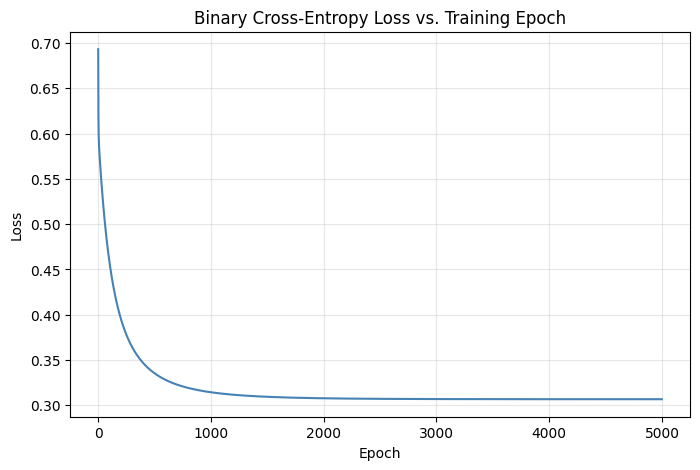

In [23]:
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title("Binary Cross-Entropy Loss vs. Training Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


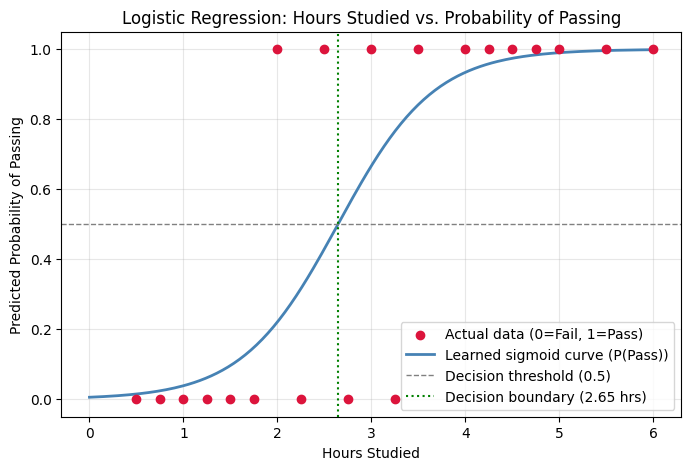

Notice the S-shape: low hours -> probability near 0, high hours -> probability near 1,
with a smooth transition around the decision boundary -- unlike the straight line from linear regression!


In [24]:
# Plot the learned sigmoid curve against our actual data points
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='crimson', zorder=3, label='Actual data (0=Fail, 1=Pass)')

x_line = np.linspace(0, 6, 200)
y_line = sigmoid(w * x_line + b)
plt.plot(x_line, y_line, color='steelblue', linewidth=2, label='Learned sigmoid curve (P(Pass))')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
plt.axvline(x=decision_boundary, color='green', linestyle=':', linewidth=1.5, label=f'Decision boundary ({decision_boundary:.2f} hrs)')

plt.title("Logistic Regression: Hours Studied vs. Probability of Passing")
plt.xlabel("Hours Studied")
plt.ylabel("Predicted Probability of Passing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice the S-shape: low hours -> probability near 0, high hours -> probability near 1,")
print("with a smooth transition around the decision boundary -- unlike the straight line from linear regression!")


# From Shannon Entropy to Binary Cross-Entropy

Lets see how **Shannon Entropy** from information theory connects **Binary Cross-Entropy (BCE)** via **Kullback-Leibler (KL) Divergence**

---

## 1. Core Intuition: What is Information?

In computer science, **information** is measured by how **surprised** you are by an outcome.
* If an event is 100% certain to happen, observing it provides **0 information** (0 surprise).
* If an event is rare or uncertain, observing it provides **high information** (high surprise).


*   **Zero Surprise:** If your friend texts you "Good morning" every single day at 7:00 AM, that text carries **0 new information**. You already knew it was coming.
*   **High Surprise:** If your friend suddenly texts you "I just won a million dollars!", that is highly unexpected. It carries **huge information**.

Mathematically, the surprise of an event $x$ with a probability $P(x)$ is calculated as:

$$I(x) = -\log_2 P(x)$$

*   **Why the negative sign?** Probabilities are fractions (like $0.5$ or $0.1$). The log of a fraction is a negative number. The negative sign at the front cancels it out to give us a positive score!

---

## 2. Shannon Entropy: Measuring Total Chaos

**Shannon Entropy $H(P)$** is the average amount of "surprise" or chaos in an entire system. It calculates the average (expected) amount of information or uncertainty across an *entire* probability distribution $P$. Instead of looking at one event.

### The Mathematical Formula
For a discrete random variable with $n$ possible outcomes:

$$H(P) = -\sum_{i=1}^{n} P(x_i) \log_2 P(x_i)$$

### The Coin Flip Example
Imagine flipping a coin. Let $p$ be the chance of getting Heads:

$$H(P) = - [p \log_2(p) + (1-p) \log_2(1-p)]$$

*   **The Rigged Coin ($p = 1$ or $p = 0$):** If a coin has Heads on both sides, the entropy is **0**. There is zero chaos. You know exactly what will happen.
*   **The Fair Coin ($p = 0.5$):** If it is a perfect 50/50 toss, the entropy hits its absolute maximum of **1 bit**. This is peak unpredictability.

---

## 3. Binary Cross-Entropy (BCE): The AI Penalty Score

In Machine Learning, we have the **True Answer ($y$)** and the **AI's Prediction ($\hat{y}$)**. 

**Binary Cross-Entropy** is the penalty score (loss function) we give an AI for bad guesses on yes/no questions. It calculates how much extra surprise happens when the AI guesses wrong.

$$BCE = - [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

### How the Penalty Works:
*   **If the true answer is Yes ($y = 1$):** The right side of the formula completely disappears. The penalty is just $-\log(\hat{y})$. If the AI guesses $0.99$ (99% sure), the penalty is almost $0$. If the AI confidently guesses $0.01$ (1% sure), the penalty explodes toward infinity!
*   **If the true answer is No ($y = 0$):** The left side disappears, and the AI is penalized based on how close it guessed to 0.

---

## 4. KL Divergence: The "Inaccuracy Distance"

**Kullback-Leibler (KL) Divergence**, written as $D_{KL}(P \parallel Q)$, measures the extra divergence, waste, or inefficiency introduced when you use a predicted distribution $Q$ to approximate a true distribution $P$. 

Think of it like a video game stat tracking **"Wasted Effort"**:
*   If the AI predicts reality perfectly, the KL Divergence is **exactly 0** (no wasted effort).
*   The worse the AI's predictions are, the higher this number climbs.

---

## 5. Connecting the Dots

All three concepts fit together in one beautiful, simple team-up formula:

$$\text{AI's Total Penalty (Cross-Entropy)} = \text{Natural Chaos (Entropy)} + \text{AI's Mistakes (KL Divergence)}$$

$$H(P, Q) = H(P) + D_{KL}(P \parallel Q)$$

| Concept | What it means | Can we change it? |
| :--- | :--- | :--- |
| **Shannon Entropy $H(P)$** | The natural noise/chaos already inside your data. | **No.** The dataset is fixed. |
| **KL Divergence $D_{KL}(P \parallel Q)$** | The exact amount of error the AI is making. | **Yes!** This shrinks as the AI learns. |
| **Cross-Entropy $H(P, Q)$** | The final score we tell the AI to minimize. | **Yes!** This is the target. |

### Why We Minimize Cross-Entropy
Because the training labels $y$ are fixed, the **Shannon Entropy $H(P)$ is a constant** (and equals 0 if your labels are hard 0s and 1s). 

Therefore, when an optimization algorithm (like Gradient Descent) minimizes **Binary Cross-Entropy**, it is mathematically identical to minimizing the **KL Divergence** to 0. When code trains an AI by **minimizing Cross-Entropy**, it is secretly crushing the **KL Divergence down to zero**. We are forcing the AI's brain to perfectly match reality!

---
# Hands-on with scikit-learn + Proper Classification Evaluation

Now let's use scikit-learn on a bigger, more realistic dataset, and learn the evaluation metrics that matter specifically for **classification** problems (very different from Day 1's MSE/RMSE).


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score, classification_report)

# Simulate a bigger dataset: 200 students
np.random.seed(1)
n = 200
hours_studied = np.random.uniform(0, 10, n)
# True underlying relationship (unknown to the model in real life) plus randomness
z_true = 1.2 * hours_studied - 5.5 + np.random.normal(0, 1.2, n)
prob_true = 1 / (1 + np.exp(-z_true))
passed = (np.random.uniform(0, 1, n) < prob_true).astype(int)  # sample actual pass/fail using true probability

df = pd.DataFrame({'hours_studied': hours_studied, 'passed': passed})
print(df.head())
print(f"\nClass balance:\n{df['passed'].value_counts()}")


   hours_studied  passed
0       4.170220       0
1       7.203245       1
2       0.001144       0
3       3.023326       0
4       1.467559       0

Class balance:
passed
1    104
0     96
Name: count, dtype: int64


### A quick but important note on class balance

Notice the count of Pass (1) vs Fail (0) above. If one class is **much** more common than the other (an "imbalanced dataset"), a model can achieve high **accuracy** just by always predicting the majority class — without learning anything useful. Keep this in mind; we'll return to it when discussing accuracy's limitations below.


In [26]:
# Train/test split -- same idea as Day 1
X = df[['hours_studied']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
    # stratify=y ensures train and test sets have similar class proportions -- important for classification!
)

print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")
print(f"Training set class balance:\n{y_train.value_counts(normalize=True).round(2)}")
print(f"\nTest set class balance:\n{y_test.value_counts(normalize=True).round(2)}")


Training set size: 150, Test set size: 50
Training set class balance:
passed
1    0.52
0    0.48
Name: proportion, dtype: float64

Test set class balance:
passed
1    0.52
0    0.48
Name: proportion, dtype: float64


In [27]:
# Train a Logistic Regression model with scikit-learn -- same pattern as Day 1's LinearRegression!
model = LogisticRegression()
model.fit(X_train, y_train)

print(f"Learned weight (w): {model.coef_[0][0]:.4f}")
print(f"Learned bias (b):   {model.intercept_[0]:.4f}")

# Two kinds of predictions we can get:
y_pred_class = model.predict(X_test)              # hard class labels: 0 or 1
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (Pass)

print("\nFirst 10 test predictions:")
comparison = pd.DataFrame({
    'hours_studied': X_test['hours_studied'].values[:10],
    'actual': y_test.values[:10],
    'predicted_class': y_pred_class[:10],
    'predicted_probability': y_pred_proba[:10].round(3)
})
print(comparison)


Learned weight (w): 0.8810
Learned bias (b):   -4.1867

First 10 test predictions:
   hours_studied  actual  predicted_class  predicted_probability
0       6.852195       1                1                  0.864
1       1.242710       1                0                  0.043
2       7.721780       1                1                  0.932
3       0.125560       0                0                  0.017
4       1.467286       0                0                  0.052
5       2.655467       0                0                  0.136
6       3.801412       0                0                  0.302
7       7.509424       1                1                  0.919
8       5.246703       0                1                  0.607
9       8.073913       1                1                  0.949


## Evaluation Metric 1: The Confusion Matrix

Before computing any single-number metric, it helps to see the **full breakdown** of correct and incorrect predictions using a **confusion matrix**:

| | Predicted: Fail (0) | Predicted: Pass (1) |
|---|---|---|
| **Actual: Fail (0)** | True Negative (TN) | False Positive (FP) |
| **Actual: Pass (1)** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP):** model predicted Pass, and student actually passed
- **True Negative (TN):** model predicted Fail, and student actually failed
- **False Positive (FP):** model predicted Pass, but student actually failed (a "false alarm")
- **False Negative (FN):** model predicted Fail, but student actually passed (a "missed detection")

Every classification metric below is built from these four numbers.


Confusion Matrix:
[[22  2]
 [ 4 22]]

(rows = actual class, columns = predicted class)

True Negatives (TN):  22
False Positives (FP): 2
False Negatives (FN): 4
True Positives (TP):  22


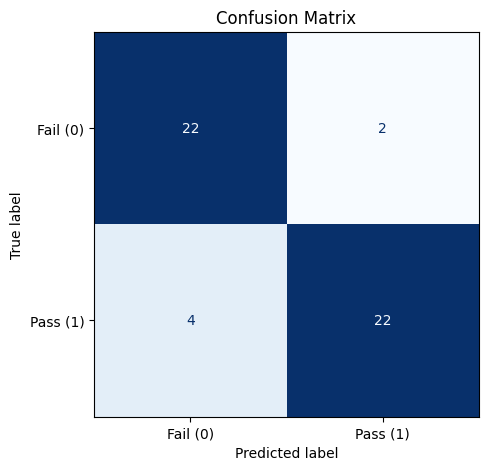

In [28]:
cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:")
print(cm)
print("\n(rows = actual class, columns = predicted class)")

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

# Visualize it
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail (0)', 'Pass (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.show()


## Evaluation Metric 2-5: Accuracy, Precision, Recall, and F1-Score

### Accuracy — "Overall, how often is the model correct?"
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
The fraction of ALL predictions that were correct.

** Why accuracy can be misleading:** Imagine 95 out of 100 patients do NOT have a rare disease. A lazy model that ALWAYS predicts "no disease" gets **95% accuracy** while being completely useless — it never correctly identifies a single actual disease case! This is why we need more metrics, especially for imbalanced datasets.

### Precision — "When the model predicts Pass, how often is it right?"
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
Out of all students the model predicted would **Pass**, what fraction actually passed? High precision means few **false alarms**.

### Recall (a.k.a. Sensitivity) — "Out of all students who actually passed, how many did the model catch?"
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
Out of all students who **actually passed**, what fraction did our model correctly identify? High recall means we rarely **miss** a true positive case.

### The Precision-Recall Trade-off
These two often trade off against each other. If we lower the classification threshold (e.g., predict "Pass" whenever probability ≥ 0.3 instead of 0.5), we'll catch more actual passers (higher recall) but also make more false alarms (lower precision). Which matters more depends on the real-world cost of each type of mistake:
- **Disease detection:** missing a sick patient (FN) is often far worse than a false alarm (FP) → prioritize **recall**
- **Spam detection:** blocking an important real email (FP) is often worse than letting one spam email through (FN) → prioritize **precision**

### F1-Score — a single number balancing both
$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$
This is the **harmonic mean** of precision and recall (harmonic mean, not simple average, because it punishes a very low value in either metric much more than a simple average would). Useful as a single balanced score when you care about both false positives and false negatives.


In [29]:
accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print(f"Accuracy:  {accuracy:.3f}  -> overall fraction of correct predictions")
print(f"Precision: {precision:.3f}  -> of predicted 'Pass' students, fraction who actually passed")
print(f"Recall:    {recall:.3f}  -> of actual 'Pass' students, fraction correctly identified")
print(f"F1-score:  {f1:.3f}  -> balanced measure of precision and recall")

print("\n--- Manual verification using the confusion matrix values ---")
print(f"Accuracy manually  = (TP+TN)/(TP+TN+FP+FN) = {(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"Precision manually = TP/(TP+FP)             = {tp/(tp+fp):.3f}")
print(f"Recall manually    = TP/(TP+FN)             = {tp/(tp+fn):.3f}")

print("\n--- scikit-learn's convenient all-in-one report ---")
print(classification_report(y_test, y_pred_class, target_names=['Fail (0)', 'Pass (1)']))


Accuracy:  0.880  -> overall fraction of correct predictions
Precision: 0.917  -> of predicted 'Pass' students, fraction who actually passed
Recall:    0.846  -> of actual 'Pass' students, fraction correctly identified
F1-score:  0.880  -> balanced measure of precision and recall

--- Manual verification using the confusion matrix values ---
Accuracy manually  = (TP+TN)/(TP+TN+FP+FN) = 0.880
Precision manually = TP/(TP+FP)             = 0.917
Recall manually    = TP/(TP+FN)             = 0.846

--- scikit-learn's convenient all-in-one report ---
              precision    recall  f1-score   support

    Fail (0)       0.85      0.92      0.88        24
    Pass (1)       0.92      0.85      0.88        26

    accuracy                           0.88        50
   macro avg       0.88      0.88      0.88        50
weighted avg       0.88      0.88      0.88        50



## Visualizing the Final Fitted Model


/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


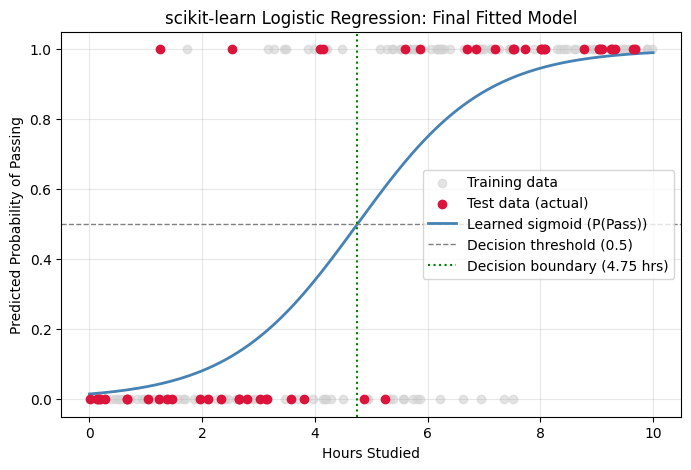

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='lightgray', label='Training data', alpha=0.6)
plt.scatter(X_test, y_test, color='crimson', label='Test data (actual)', zorder=3)

x_line = np.linspace(0, 10, 200).reshape(-1, 1)
y_line_proba = model.predict_proba(x_line)[:, 1]
plt.plot(x_line, y_line_proba, color='steelblue', linewidth=2, label='Learned sigmoid (P(Pass))')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold (0.5)')

boundary = -model.intercept_[0] / model.coef_[0][0]
plt.axvline(x=boundary, color='green', linestyle=':', linewidth=1.5, label=f'Decision boundary ({boundary:.2f} hrs)')

plt.title("scikit-learn Logistic Regression: Final Fitted Model")
plt.xlabel("Hours Studied")
plt.ylabel("Predicted Probability of Passing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Evaluation Metric 6: ROC Curve and AUC (Check yourself during free hours)

Accuracy/precision/recall all depend on picking ONE fixed threshold (usually 0.5). The **ROC curve** (Receiver Operating Characteristic) shows model performance **across ALL possible thresholds** at once.

It plots:
- **X-axis:** False Positive Rate = $\frac{FP}{FP+TN}$ (how often we falsely raise an alarm)
- **Y-axis:** True Positive Rate (=Recall) = $\frac{TP}{TP+FN}$ (how many real positives we catch)

As we sweep the threshold from 1 (very strict, few positives predicted) down to 0 (very lenient, everything predicted positive), we trace out a curve.

### AUC (Area Under the Curve)
A single number summarizing the ROC curve:
- **AUC = 1.0** → perfect classifier (always ranks actual positives higher than actual negatives)
- **AUC = 0.5** → no better than random guessing (a diagonal line)
- **AUC < 0.5** → worse than random (rare, usually indicates something is wrong, e.g. flipped labels)

AUC is especially useful because it doesn't depend on picking one specific threshold — it measures how well the model **ranks** predictions overall.


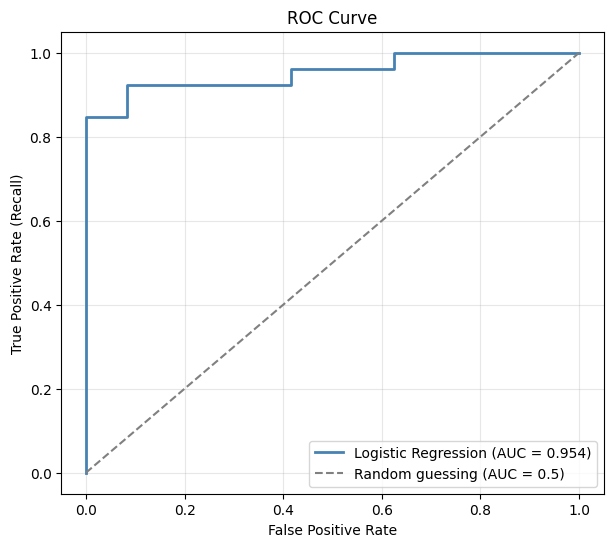

AUC Score: 0.954
An AUC well above 0.5 confirms our model has genuinely learned a useful pattern,
not just guessing randomly.


In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing (AUC = 0.5)')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {auc:.3f}")
print("An AUC well above 0.5 confirms our model has genuinely learned a useful pattern,")
print("not just guessing randomly.")


## Linear Regression (Day 1) vs. Logistic Regression (Day 2) — Side by Side

| Aspect | Linear Regression | Logistic Regression |
|---|---|---|
| Predicts | Continuous number | Probability (0 to 1) → class label |
| Model | $\hat{y} = wx+b$ | $\hat{y} = \sigma(wx+b)$ |
| Output range | $(-\infty, \infty)$ | $(0, 1)$ |
| Loss function | MSE | Binary Cross-Entropy (Log Loss) |
| Learning method | Gradient Descent | Gradient Descent (same gradient form!) |
| Evaluation | MSE, RMSE | Accuracy, Precision, Recall, F1 |
| scikit-learn class | `LinearRegression` | `LogisticRegression` |

**Despite the name "regression," Logistic Regression is a classification algorithm** — the name is a historical quirk because it's built directly on top of a linear regression-style equation.


### Practice Exercises (try before next class)
1. Change the decision threshold from 0.5 to 0.3 in the from-scratch model (predict "Pass" if probability ≥ 0.3). How does this affect precision vs. recall?
2. Make the dataset imbalanced (e.g., only 10% "Pass" students) and retrain. Watch what happens to accuracy vs. F1-score — which one still tells the truth about model quality?
3. Add a second feature (e.g., `attendance_rate`) to the scikit-learn dataset. Does AUC improve?
4. Try `LogisticRegression(class_weight='balanced')` in scikit-learn on an imbalanced dataset — look up what this parameter does and why it might help.